<a href="https://colab.research.google.com/github/rmoy1-clt/Intro-to-ML/blob/main/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW4: Support Vector Machines (SVM and SVR)

**Name:** Ryan Moy &nbsp;|&nbsp; **Student ID:** 801400597 &nbsp;|&nbsp; **Homework:** HW4

**GitHub:** https://github.com/rmoy1-clt/Intro-to-ML/blob/main/HW4.ipynb

**Datasets:** Breast Cancer Wisconsin dataset from `sklearn.datasets` (Problem 1) and `Housing.csv` (Problem 2)

**Split:** 80% training / 20% evaluation (test) for both problems

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import r2_score, mean_squared_error

SEED = 42
KERNELS = ['linear', 'poly', 'rbf', 'sigmoid']

---
# Problem 1: SVM classifier on the cancer dataset



In [2]:
cancer = load_breast_cancer()
Xc = cancer.data
yc = 1 - cancer.target                     # 1 = malignant, 0 = benign
print(Xc.shape, '  malignant:', yc.sum(), '  benign:', (yc == 0).sum())

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED)
sc_c = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s = sc_c.transform(Xc_tr), sc_c.transform(Xc_te)
print('training:', Xc_tr_s.shape, '  test:', Xc_te_s.shape)

(569, 30)   malignant: 212   benign: 357
training: (455, 30)   test: (114, 30)


## 1.1 Train one SVM per kernel



In [3]:
def make_svc(kernel):
    if kernel in ['poly', 'sigmoid']:
        return SVC(kernel=kernel, C=1.0, degree=3, coef0=1.0)
    return SVC(kernel=kernel, C=1.0)

def cls_report(y_true, y_pred):
    return {'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall':    recall_score(y_true, y_pred),
            'F1 score':  f1_score(y_true, y_pred)}

svm_models, svm_res = {}, {}
for k in KERNELS:
    m = make_svc(k).fit(Xc_tr_s, yc_tr)
    svm_models[k] = m
    svm_res[k] = cls_report(yc_te, m.predict(Xc_te_s))
    svm_res[k]['Train acc'] = accuracy_score(yc_tr, m.predict(Xc_tr_s))
    svm_res[k]['# support vectors'] = int(m.n_support_.sum())

svm_table = pd.DataFrame(svm_res).T[['Train acc', 'Accuracy', 'Precision', 'Recall', 'F1 score', '# support vectors']]
print(svm_table.round(4))

         Train acc  Accuracy  Precision  Recall  F1 score  # support vectors
linear      0.9868    0.9561     0.9318  0.9535    0.9425               36.0
poly        0.9934    0.9825     1.0000  0.9535    0.9762               59.0
rbf         0.9890    0.9825     1.0000  0.9535    0.9762              104.0
sigmoid     0.9033    0.9298     0.9268  0.8837    0.9048               91.0


## 1.2 Logistic regression from HW3 (for comparison)



In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic(X, y, lr=0.1, n_iter=2000):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    theta = np.zeros(Xb.shape[1])
    for _ in range(n_iter):
        theta -= lr * Xb.T @ (sigmoid(Xb @ theta) - y) / len(y)
    return theta

theta_lr = train_logistic(Xc_tr_s, yc_tr)
yp_lr = (sigmoid(np.hstack([np.ones((len(Xc_te_s), 1)), Xc_te_s]) @ theta_lr) >= 0.5).astype(int)
log_res = cls_report(yc_te, yp_lr)
for k, v in log_res.items():
    print(f'{k:<10} {v:.4f}')

Accuracy   0.9912
Precision  1.0000
Recall     0.9767
F1 score   0.9882


## 1.3 Plots: accuracy, precision and recall for each kernel vs logistic regression

                Accuracy  Precision  Recall
SVM linear         95.61      93.18   95.35
SVM poly           98.25     100.00   95.35
SVM rbf            98.25     100.00   95.35
SVM sigmoid        92.98      92.68   88.37
Logistic (HW3)     99.12     100.00   97.67


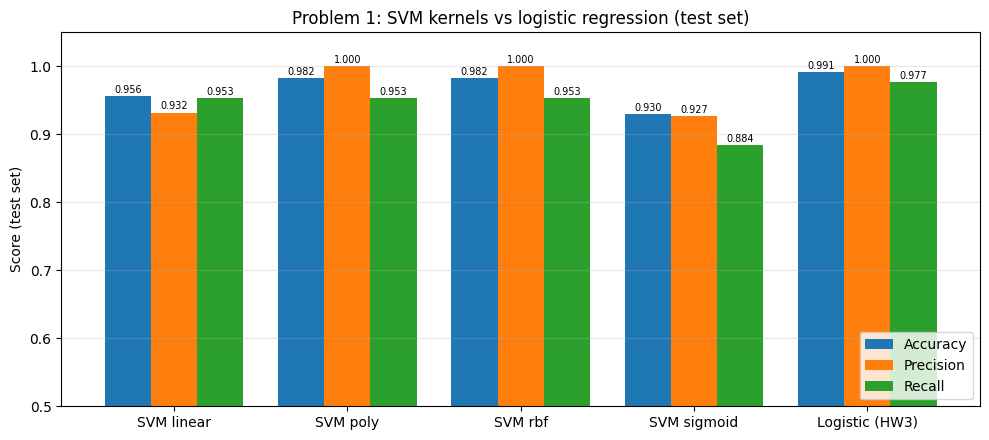

In [5]:
comp = pd.DataFrame({**{f'SVM {k}': {m: svm_res[k][m] for m in ['Accuracy', 'Precision', 'Recall']} for k in KERNELS},
                     'Logistic (HW3)': {m: log_res[m] for m in ['Accuracy', 'Precision', 'Recall']}}).T
print((comp * 100).round(2))

ax = comp.plot(kind='bar', figsize=(10, 4.5), width=0.8, color=['tab:blue', 'tab:orange', 'tab:green'])
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=7, padding=1)
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Score (test set)')
ax.set_title('Problem 1: SVM kernels vs logistic regression (test set)')
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

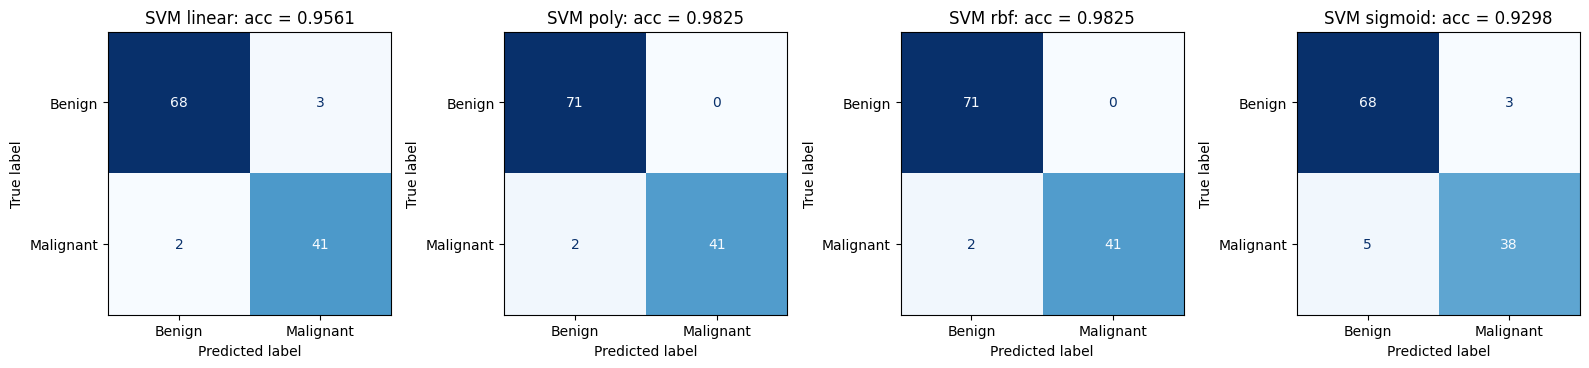

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, k in zip(axes, KERNELS):
    cm = confusion_matrix(yc_te, svm_models[k].predict(Xc_te_s))
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'SVM {k}: acc = {svm_res[k]["Accuracy"]:.4f}')
plt.tight_layout(); plt.show()

---
# Problem 2: SVR on the housing dataset



In [7]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Intro-to-ML/Datasets/Housing.csv'
df = pd.read_csv(file_path)
print(df.shape)
df.head()

Mounted at /content/drive
(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
BINARY = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for c in BINARY:
    df[c] = df[c].map({'yes': 1, 'no': 0})

FEATS = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement',
         'hotwaterheating', 'airconditioning', 'parking', 'prefarea']
X = df[FEATS].values.astype(float)
y = df['price'].values.astype(float)

# same 80/20 split as HW2
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(df))
k    = int(np.floor(0.8 * len(df)))
TR, TE = perm[:k], perm[k:]
Xh_tr, Xh_te, yh_tr, yh_te = X[TR], X[TE], y[TR], y[TE]
print('training:', Xh_tr.shape, '  test:', Xh_te.shape)

# Standardize the inputs (fit on training only).
sx = StandardScaler().fit(Xh_tr)
Xh_tr_s, Xh_te_s = sx.transform(Xh_tr), sx.transform(Xh_te)

# SVR uses an epsilon tube of 0.1, so the price (in the millions) is also standardized for training.
# Predictions are converted back to dollars before any metric is computed.
sy = StandardScaler().fit(yh_tr.reshape(-1, 1))
yh_tr_s = sy.transform(yh_tr.reshape(-1, 1)).ravel()
to_dollars = lambda v: sy.inverse_transform(v.reshape(-1, 1)).ravel()

training: (436, 11)   test: (109, 11)


## 2.1 Train one SVR per kernel


In [9]:
grids = {
    'linear':  {'C': [0.1, 1, 10]},
    'poly':    {'C': [0.1, 1, 10], 'degree': [2, 3], 'coef0': [1]},
    'rbf':     {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 'scale']},
    'sigmoid': {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1]},
}

def reg_report(y_true, y_pred):
    return {'R2': r2_score(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MSE': mean_squared_error(y_true, y_pred)}

svr_models, svr_res = {}, {}
for kname in KERNELS:
    gs = GridSearchCV(SVR(kernel=kname), grids[kname], cv=5, scoring='r2').fit(Xh_tr_s, yh_tr_s)
    svr_models[kname] = gs.best_estimator_
    svr_res[kname] = {'Best params': gs.best_params_,
                      'Train R2': r2_score(yh_tr, to_dollars(gs.predict(Xh_tr_s))),
                      **reg_report(yh_te, to_dollars(gs.predict(Xh_te_s)))}
    print(f'{kname:<8} best params: {gs.best_params_}')

svr_table = pd.DataFrame(svr_res).T[['Train R2', 'R2', 'RMSE']].astype(float)
print(svr_table.round(4))

linear   best params: {'C': 0.1}
poly     best params: {'C': 0.1, 'coef0': 1, 'degree': 2}
rbf      best params: {'C': 10, 'gamma': 0.01}
sigmoid  best params: {'C': 10, 'gamma': 0.01}
         Train R2      R2          RMSE
linear     0.6570  0.6832  1.057167e+06
poly       0.7089  0.6858  1.052869e+06
rbf        0.7342  0.6724  1.075053e+06
sigmoid    0.6440  0.6710  1.077303e+06


## 2.2 Linear regression with an L2 penalty (HW2 Problem 3b)



In [10]:
ridge = Ridge(alpha=100).fit(Xh_tr_s, yh_tr)
ridge_res = {'Train R2': r2_score(yh_tr, ridge.predict(Xh_tr_s)), **reg_report(yh_te, ridge.predict(Xh_te_s))}
for k, v in ridge_res.items():
    print(f'{k:<9} {v:,.4f}')

Train R2  0.6592
R2        0.6943
RMSE      1,038,400.4865
MSE       1,078,275,570,403.0444


In [11]:
reg_comp = pd.DataFrame({**{f'SVR {k}': {m: svr_res[k][m] for m in ['Train R2', 'R2', 'RMSE']} for k in KERNELS},
                         'Linear + L2 (HW2)': {m: ridge_res[m] for m in ['Train R2', 'R2', 'RMSE']}}).T
reg_comp = reg_comp.rename(columns={'R2': 'Test R2', 'RMSE': 'Test RMSE'})
pd.options.display.float_format = '{:,.4f}'.format
print(reg_comp)

                   Train R2  Test R2      Test RMSE
SVR linear           0.6570   0.6832 1,057,166.6116
SVR poly             0.7089   0.6858 1,052,869.2746
SVR rbf              0.7342   0.6724 1,075,053.2387
SVR sigmoid          0.6440   0.6710 1,077,303.2167
Linear + L2 (HW2)    0.6592   0.6943 1,038,400.4865


## 2.3 Plots


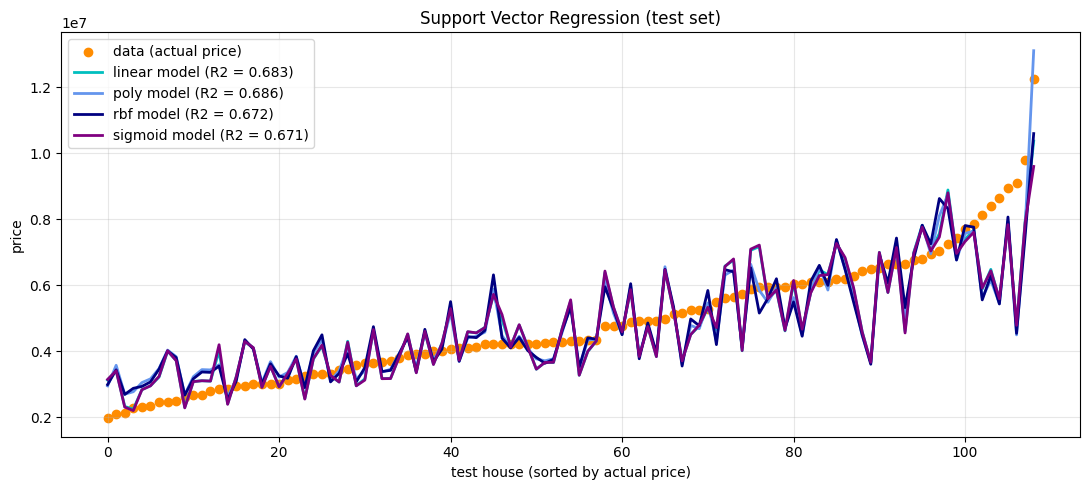

In [12]:
order = np.argsort(yh_te)
xs = np.arange(len(order))
colors = {'linear': 'c', 'poly': 'cornflowerblue', 'rbf': 'navy', 'sigmoid': 'purple'}
lw = 2
plt.figure(figsize=(11, 5))
plt.scatter(xs, yh_te[order], color='darkorange', label='data (actual price)')
for kname in KERNELS:
    plt.plot(xs, to_dollars(svr_models[kname].predict(Xh_te_s))[order], color=colors[kname], lw=lw,
             label=f'{kname} model (R2 = {svr_res[kname]["R2"]:.3f})')
plt.xlabel('test house (sorted by actual price)')
plt.ylabel('price')
plt.title('Support Vector Regression (test set)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

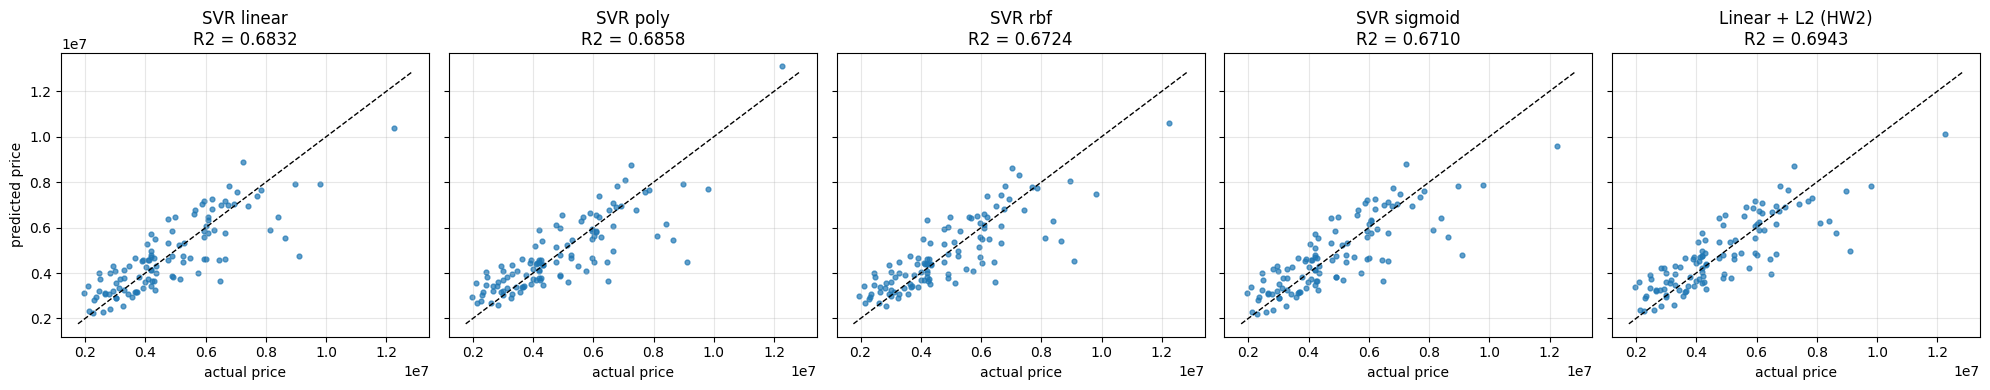

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
preds = {f'SVR {k}': to_dollars(svr_models[k].predict(Xh_te_s)) for k in KERNELS}
preds['Linear + L2 (HW2)'] = ridge.predict(Xh_te_s)
lims = [yh_te.min() * 0.9, yh_te.max() * 1.05]
for ax, (name, p) in zip(axes, preds.items()):
    ax.scatter(yh_te, p, s=12, alpha=0.7)
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_title(f'{name}\nR2 = {r2_score(yh_te, p):.4f}')
    ax.set_xlabel('actual price'); ax.grid(alpha=0.3)
axes[0].set_ylabel('predicted price')
plt.tight_layout(); plt.show()

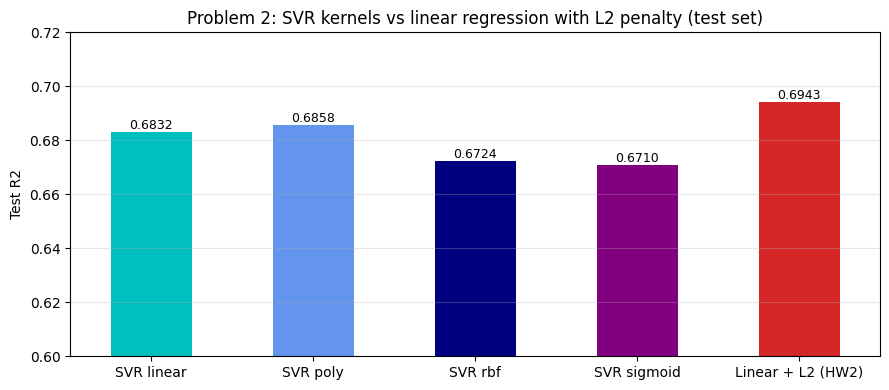

In [14]:
ax = reg_comp['Test R2'].plot(kind='bar', figsize=(9, 4),
                             color=['c', 'cornflowerblue', 'navy', 'purple', 'tab:red'])
ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=9)
ax.set_ylim(0.6, 0.72); ax.set_ylabel('Test R2')
ax.set_title('Problem 2: SVR kernels vs linear regression with L2 penalty (test set)')
plt.xticks(rotation=0); plt.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()